# Prototype: DGA Rule Engine + Trend Engine + Composite Risk Score

**PKM F4 — Unified Trend & Correlation Analytics untuk PD dan DGA**

Notebook ini mengimplementasikan 3 dari 4 kapabilitas yang diusulkan di makalah PKM
(`docs/qic-pd-unified-trend-analytics.md`):

1. **DGA Rule Engine** — screening IEEE C57.104-2019 (Status 1/2/3) berdasarkan kadar gas individual,
   Delta Value, dan Gas Rate, dibandingkan terhadap 4 tabel batas (Tabel 3.2–3.5) yang bergantung
   pada rasio O2/N2 dan usia trafo.
2. **Trend Engine** — Moving Average & Compare Historis generik per gas per aset.
3. **Composite Risk Score** — Isolation Forest (unsupervised) di atas fitur tren, cross-sectional
   antar aset (karena histori tiap aset masih pendek, 2-4 titik).

**Sumber data**: 21 transformator dipilih dari 3 laporan riil PT Petrolab Services untuk
PT Pupuk Sriwidjaja Palembang (Desember 2023, Maret 2024, Juli 2024), mencakup kasus
Normal, Partial Discharge, Thermal Cellulose, dan Stray Gassing — dipilih supaya rule engine
bisa divalidasi terhadap kesimpulan lab yang sudah ada (ground truth), bukan cuma dummy data.

**Catatan penting**: nilai batas Tabel 3.2–3.5 di bawah adalah rekonstruksi dari ringkasan
"DGA — Panduan Teknis" (beberapa sel di dokumen aslinya merged/gabungan antar kolom usia).
Sudah dicocokkan terhadap 1 baris data riil (TR-40, kategori low-O2N2/age 1-9) dan hasilnya
identik dengan limit yang tertulis di laporan lab — tapi tetap perlu divalidasi ulang ke teks
resmi IEEE C57.104-2019 sebelum dipakai di luar prototype ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## 1. Load & Bentuk Data

Data di bawah ditranskripsi langsung dari tabel "Dissolved Gas Analysis (DGA)" pada laporan
Petrolab (nilai ppm), bukan dummy/sintetis. `lab_status` dan `lab_fault_type` adalah kesimpulan
asli lab ("Equipment Condition" dan "Fault Type"), dipakai sebagai ground truth validasi.

In [2]:
# asset_id, manufacture_year, sample_date, gas ppm (h2..co2), o2, n2, lab_status (1/2/3), lab_fault_type
raw_rows = [
    # --- Normal baseline ---
    ("TR-26", 1974, "2023-03-27", 2, 206, 415, 14, 0.0, 276, 2090, 117, 63024, 3, "Normal"),
    ("TR-26", 1974, "2023-07-25", 6, 205, 407, 14, 0.0, 313, 2037, 117, 68942, 2, "Normal"),
    ("TR-26", 1974, "2023-11-23", 2, 189, 391, 14, 0.0, 297, 2016, 117, 83716, 1, "Normal"),
    ("TR-27", 2012, "2023-03-27", 5, 5, 5, 8, 0.0, 521, 4513, 11646, 66190, 1, "Normal"),
    ("TR-27", 2012, "2023-11-23", 8, 4, 3, 8, 0.0, 594, 4813, 7035, 72814, 1, "Normal"),
    ("1N-TR-001", 2014, "2023-05-03", 3, 7, 3, 8, 0.0, 723, 6254, 1183, 62544, 2, "Normal"),
    ("1N-TR-001", 2014, "2024-02-06", 3, 10, 3, 8, 0.0, 702, 6854, 1694, 71536, 1, "Normal"),
    ("2N-TR-001", 2018, "2023-05-03", 26, 6, 3, 8, 0.0, 441, 4365, 3163, 64811, 1, "Normal"),
    ("2N-TR-001", 2018, "2024-02-07", 18, 10, 4, 8, 0.0, 376, 4799, 3426, 65769, 1, "Normal"),
    ("TR-31", 1975, "2023-05-03", 0, 54, 73, 67, 0.0, 675, 5987, 298, 55938, 1, "Normal"),
    ("TR-31", 1975, "2024-02-06", 5, 55, 86, 65, 0.0, 462, 6415, 1826, 67197, 1, "Normal"),
    ("F6P-1001MVTR", 2014, "2023-03-27", 0, 0, 0, 8, 0.0, 77, 1884, 26547, 57110, 1, "Normal"),
    ("F6P-1001MVTR", 2014, "2023-11-23", 0, 0, 0, 8, 0.0, 78, 1723, 24739, 53074, 1, "Normal"),
    ("TR-314C-Srigading", 2010, "2024-02-07", 0, 11, 16, 8, 0.0, 174, 2760, 6480, 60750, 1, "Normal"),
    ("TR-314C-Srigading", 2010, "2024-06-06", 7, 12, 18, 8, 0.0, 189, 2941, 157, 61010, 1, "Normal"),

    # --- Stray Gassing (heating <200C, bukan fault aktif) ---
    ("TR-Kolam-Renang", 2010, "2024-02-06", 0, 17, 20, 8, 0.0, 449, 2376, 117, 68674, 1, "Normal"),
    ("TR-Kolam-Renang", 2010, "2024-03-05", 5, 25, 26, 28, 0.0, 345, 2415, 363, 63626, 2, "Stray Gassing"),
    ("F5O-TR55", 1991, "2016-11-18", 1088, 213, 215, 8, 0.0, 471, 9870, 1821, 44831, 1, "Normal"),
    ("F5O-TR55", 1991, "2020-09-17", 439, 153, 352, 12, 0.0, 126, 6319, 503, 66486, 1, "Normal"),
    ("F5O-TR55", 1991, "2023-05-23", 424, 165, 287, 8, 0.0, 136, 11931, 117, 74704, 3, "Stray Gassing"),
    ("F5O-TR55", 1991, "2024-06-05", 420, 165, 288, 10, 0.0, 116, 11852, 117, 79142, 2, "Stray Gassing"),
    ("F5O-TR512A", 1991, "2016-11-18", 8, 184, 258, 12, 0.0, 407, 3303, 1, 42403, 1, "Normal"),
    ("F5O-TR512A", 1991, "2020-09-17", 30, 136, 391, 16, 0.0, 104, 1572, 60, 73991, 1, "Normal"),
    ("F5O-TR512A", 1991, "2023-05-23", 0, 130, 284, 11, 0.0, 69, 2662, 117, 71687, 3, "Stray Gassing"),
    ("F5O-TR512A", 1991, "2024-06-05", 8, 137, 299, 12, 0.0, 93, 2684, 186, 80150, 2, "Stray Gassing"),

    # --- Partial Discharge (H2 dominan) ---
    ("TR-40", 2014, "2023-03-27", 2559, 3, 3, 8, 0.0, 390, 1623, 2512, 68511, 3, "Partial Discharge"),
    ("TR-40", 2014, "2023-07-25", 2593, 3, 3, 8, 0.0, 438, 1880, 117, 73161, 3, "Partial Discharge"),
    ("TR-40", 2014, "2023-11-23", 2541, 3, 3, 8, 0.0, 464, 1907, 117, 81772, 3, "Partial Discharge"),
    ("TR-44", 1976, "2023-03-27", 619, 150, 54, 8, 0.0, 118, 3165, 22257, 58465, 3, "Partial Discharge"),
    ("TR-44", 1976, "2023-07-25", 21126, 1526, 416, 8, 3.16, 892, 16948, 117, 42226, 3, "Partial Discharge"),
    ("TR-44", 1976, "2023-11-23", 8385, 1428, 543, 8, 2.93, 488, 11733, 117, 45701, 3, "Partial Discharge"),
    ("TR-221", 2008, "2023-05-23", 47966, 9841, 2895, 8, 0.0, 42, 811, 117, 2910, 3, "Partial Discharge"),
    ("TR-221", 2008, "2024-06-05", 50438, 10812, 3088, 8, 0.0, 2, 726, 117, 1727, 3, "Partial Discharge"),
    ("TR-Melati-216", 1990, "2023-05-23", 707, 11, 12, 8, 0.0, 173, 5658, 183, 70915, 3, "Partial Discharge"),
    ("TR-Melati-216", 1990, "2024-06-05", 1025, 11, 16, 8, 0.0, 205, 6029, 117, 83385, 3, "Partial Discharge"),
    ("TR-YDPK", 2018, "2023-05-23", 8472, 133, 19, 8, 0.0, 674, 3947, 117, 51625, 3, "Partial Discharge"),
    ("TR-YDPK", 2018, "2024-06-06", 10529, 251, 35, 8, 0.0, 381, 4960, 196, 61132, 3, "Partial Discharge"),
    ("TR-34", 1975, "2023-05-03", 1836, 235, 176, 12, 1.95, 161, 2878, 18171, 58152, 3, "Partial Discharge"),
    ("TR-34", 1975, "2024-06-06", 5921, 543, 266, 24, 1.78, 606, 8958, 7621, 53972, 3, "Partial Discharge"),
    ("TR-AOP-P4", 1989, "2023-05-03", 6228, 336, 39, 8, 0.0, 582, 15206, 117, 63948, 3, "Partial Discharge"),
    ("TR-AOP-P4", 1989, "2024-02-06", 5105, 325, 38, 8, 0.0, 598, 15681, 149, 67292, 3, "Partial Discharge"),

    # --- Thermal Cellulose (CO/CO2 tinggi, dekomposisi kertas) ---
    ("TR-1-HV-4", 2021, "2023-05-23", 4, 28, 3, 8, 0.0, 1140, 6000, 2871, 75012, 3, "Thermal Cellulose"),
    ("TR-1-HV-4", 2021, "2024-06-05", 2, 29, 3, 8, 0.0, 1325, 7152, 1125, 81304, 3, "Thermal Cellulose"),

    # --- Attention / furan End of Life (insulasi kritis, DGA sendiri borderline) ---
    ("TR-311B", 1993, "2023-03-29", 85, 14, 3, 8, 0.0, 480, 18735, 1367, 70057, 3, "Mild Overheating Paper"),
    ("TR-311B", 1993, "2023-07-25", 2, 3, 3, 8, 0.0, 235, 6365, 15167, 52426, 2, "Mild Overheating Paper"),
    ("TR-311B", 1993, "2023-11-23", 4, 3, 3, 8, 0.0, 258, 6450, 12905, 51627, 2, "Mild Overheating Paper"),
    ("TR-312A", 1985, "2023-03-29", 2, 3, 4, 16, 0.0, 271, 5545, 25555, 60244, 2, "Attention"),
    ("TR-312A", 1985, "2023-07-25", 2, 3, 4, 14, 0.0, 242, 5358, 20935, 54405, 1, "Attention"),
    ("TR-312A", 1985, "2023-11-23", 2, 6, 4, 16, 0.0, 240, 4470, 16941, 47307, 2, "Attention"),

    # --- Aset baru dari transkripsi 3 laporan Petrolab (Des-2023/Mar-2024/Jul-2024) ---
    # --- Normal ---
    ("TR-36", 1974, "2023-03-27", 4, 11, 10, 0, 0.0, 299, 1689, 1749, 67663, 1, "Normal"),
    ("TR-36", 1974, "2023-11-23", 4, 12, 10, 0, 0.0, 351, 1854, 238, 88555, 1, "Normal"),
    ("TR-41", 1976, "2023-03-27", 2, 3, 3, 8, 0.0, 21, 956, 27939, 61118, 1, "Normal"),
    ("TR-41", 1976, "2023-11-23", 2, 3, 3, 8, 0.0, 47, 1231, 17968, 47678, 1, "Normal"),
    ("TR-42", 1976, "2023-03-27", 2, 3, 3, 8, 0.0, 13, 802, 27266, 58816, 1, "Normal"),
    ("TR-42", 1976, "2023-11-23", 2, 3, 3, 8, 0.0, 22, 1063, 17848, 47059, 1, "Normal"),
    ("TR-43", 1976, "2023-03-27", 3, 25, 37, 8, 0.0, 140, 3225, 11099, 60929, 1, "Normal"),
    ("TR-43", 1976, "2023-11-23", 10, 31, 39, 8, 0.0, 295, 4417, 923, 84424, 1, "Normal"),
    ("TR-51A", 1999, "2016-11-18", 5, 32, 23, 6, 0.0, 353, 5008, 1079, 45313, 1, "Normal"),
    ("TR-51A", 1999, "2020-09-18", 7, 26, 39, 8, 0.0, 205, 2281, 621, 67632, 1, "Normal"),
    ("TR-51A", 1999, "2023-03-27", 2, 15, 24, 30, 0.0, 122, 2157, 524, 71485, 1, "Normal"),
    ("TR-51A", 1999, "2023-11-23", 2, 14, 24, 29, 0.0, 132, 2319, 117, 94757, 1, "Normal"),
    ("TR-51", 1991, "2016-11-18", 272, 5, 1, 1, 0.0, 110, 2832, 15492, 43137, 1, "Normal"),
    ("TR-51", 1991, "2020-09-18", 2, 3, 3, 8, 0.0, 13, 387, 38207, 73204, 1, "Normal"),
    ("TR-51", 1991, "2023-03-27", 3, 3, 3, 8, 0.0, 14, 775, 27529, 59938, 1, "Normal"),
    ("TR-51", 1991, "2023-11-23", 2, 4, 3, 8, 0.0, 17, 780, 18994, 47068, 1, "Normal"),
    ("TR-52", 1991, "2016-11-18", 1594, 27, 13, 1, 0.0, 562, 11279, 1594, 43560, 1, "Normal"),
    ("TR-52", 1991, "2020-09-18", 914, 54, 8, 8, 0.0, 260, 2845, 15504, 67746, 1, "Normal"),
    ("TR-52", 1991, "2023-03-27", 9, 5, 3, 8, 0.0, 117, 2332, 15622, 62254, 1, "Normal"),
    ("TR-52", 1991, "2023-11-23", 9, 6, 3, 8, 0.0, 193, 2993, 10017, 66237, 1, "Normal"),
    ("TR-56", 1991, "2023-03-27", 2, 3, 3, 8, 0.0, 8, 712, 28479, 60154, 1, "Normal"),
    ("TR-56", 1991, "2023-11-23", 2, 3, 3, 8, 0.0, 11, 678, 20225, 47793, 1, "Normal"),
    ("TR-57", 1991, "2023-03-27", 2, 3, 3, 8, 0.0, 179, 1393, 10175, 61296, 1, "Normal"),
    ("TR-57", 1991, "2023-11-23", 3, 3, 3, 8, 0.0, 241, 1765, 4506, 72783, 1, "Normal"),
    ("TR-TRANSPORT-210", 2003, "2023-03-27", 2, 24, 33, 8, 0.0, 112, 2515, 206, 68152, 1, "Normal"),
    ("TR-TRANSPORT-210", 2003, "2023-11-23", 2, 28, 39, 8, 0.0, 112, 2538, 322, 91668, 1, "Normal"),
    ("TR-PEPAYA-214", 1999, "2023-03-27", 4, 3, 3, 8, 0.0, 35, 2093, 23908, 53160, 1, "Normal"),
    ("TR-PEPAYA-214", 1999, "2023-11-23", 4, 3, 3, 8, 0.0, 56, 2156, 13455, 41910, 1, "Normal"),
    ("TR-PEPAYA-215", 1999, "2023-03-27", 2, 3, 3, 8, 0.0, 27, 817, 25838, 55471, 1, "Normal"),
    ("TR-PEPAYA-215", 1999, "2023-11-23", 2, 3, 3, 8, 0.0, 29, 864, 17039, 41914, 1, "Normal"),
    ("TR-DIKLAT", 1990, "2023-03-27", 3, 3, 3, 8, 0.0, 86, 4287, 22547, 60903, 1, "Normal"),
    ("TR-DIKLAT", 1990, "2023-11-23", 4, 3, 3, 8, 0.0, 106, 4796, 12762, 63066, 1, "Normal"),
    ("F6P-2001MVTR", 2014, "2023-03-27", 2, 3, 3, 8, 0.0, 209, 2756, 23877, 54829, 1, "Normal"),
    ("F6P-2001MVTR", 2014, "2023-11-23", 2, 3, 3, 8, 0.0, 205, 2593, 15321, 42754, 1, "Normal"),
    ("F6P-1001LVTR", 2014, "2023-03-27", 24, 3, 3, 8, 0.0, 128, 1389, 3172, 59756, 1, "Normal"),
    ("F6P-1001LVTR", 2014, "2023-11-23", 38, 3, 3, 8, 0.0, 131, 1373, 1634, 68753, 1, "Normal"),
    ("F6P-2001LVTR", 2014, "2023-03-27", 8, 3, 3, 8, 0.0, 124, 1071, 16777, 54875, 1, "Normal"),
    ("F6P-2001LVTR", 2014, "2023-11-23", 16, 3, 3, 8, 0.0, 149, 1119, 4289, 59295, 1, "Normal"),
    ("2N-TR-002", 2018, "2023-05-03", 362, 29, 6, 8, 0.0, 176, 7228, 9828, 60055, 3, "Attention"),
    ("2N-TR-002", 2018, "2024-02-07", 10, 13, 6, 8, 0.0, 46, 4172, 22125, 54441, 2, "Attention"),
    ("GP-3001LVTR", 2014, "2023-05-03", 89, 6, 4, 8, 0.0, 122, 1043, 337, 57319, 2, "Normal"),
    ("GP-3001LVTR", 2014, "2024-02-06", 74, 3, 3, 8, 0.0, 87, 931, 1920, 41169, 1, "Normal"),
    ("F6P-3001MVTR", 2014, "2023-03-27", 2, 3, 3, 8, 0.0, 77, 1884, 26547, 57110, 1, "Normal"),
    ("F6P-3001MVTR", 2014, "2024-02-06", 2, 3, 3, 8, 0.0, 78, 1723, 24739, 53074, 1, "Normal"),
    ("GP-3002LVTR", 2014, "2023-05-03", 2, 3, 3, 8, 0.0, 131, 1142, 23356, 51766, 1, "Normal"),
    ("GP-3002LVTR", 2014, "2024-02-06", 2, 3, 3, 8, 0.0, 124, 1143, 24034, 53606, 1, "Normal"),
    ("GP-3002MVTR", 2014, "2023-05-03", 2, 3, 3, 8, 0.0, 92, 2028, 22334, 48959, 1, "Normal"),
    ("GP-3002MVTR", 2014, "2024-02-06", 2, 3, 3, 8, 0.0, 85, 1933, 24447, 53687, 1, "Normal"),
    ("3N-TR-002", 2018, "2023-05-03", 2, 4, 3, 8, 0.0, 239, 1972, 10193, 62697, 1, "Normal"),
    ("3N-TR-002", 2018, "2024-02-07", 7, 3, 3, 8, 0.0, 255, 2239, 9059, 64051, 1, "Normal"),
    ("TR-317-Rasamala", 1999, "2023-05-03", 27, 3, 3, 8, 0.0, 86, 2487, 18789, 47955, 1, "Normal"),
    ("TR-317-Rasamala", 1999, "2024-02-06", 19, 3, 3, 8, 0.0, 84, 2372, 20848, 51538, 1, "Normal"),
    ("TR-32", 1975, "2023-05-03", 76, 15, 13, 33, 0.0, 675, 5987, 298, 55938, 1, "Normal"),
    ("TR-32", 1975, "2024-02-06", 66, 18, 17, 35, 0.0, 462, 6415, 1826, 67197, 1, "Normal"),
    ("TR-325-Rasamala", 1999, "2023-05-03", 2, 3, 3, 8, 0.0, 82, 2242, 20026, 47444, 1, "Normal"),
    ("TR-325-Rasamala", 1999, "2024-02-06", 2, 3, 3, 8, 0.0, 80, 2937, 21444, 51941, 1, "Normal"),
    ("TR-329-Gurame", 1999, "2023-05-04", 2, 4, 3, 8, 0.0, 89, 3370, 20285, 48424, 1, "Normal"),
    ("TR-329-Gurame", 1999, "2024-02-07", 2, 3, 3, 8, 0.0, 89, 3604, 20500, 50854, 1, "Normal"),
    ("TR-45", 1976, "2023-05-03", 4, 44, 167, 9, 0.0, 145, 4314, 7149, 62865, 2, "Normal"),
    ("TR-45", 1976, "2024-02-06", 5, 55, 188, 13, 0.0, 176, 4875, 198, 63066, 1, "Normal"),
    ("TR-46", 1976, "2023-05-03", 7, 36, 56, 8, 0.0, 219, 3786, 572, 66970, 1, "Normal"),
    ("TR-46", 1976, "2024-02-06", 5, 32, 59, 8, 0.0, 190, 3587, 783, 64524, 1, "Normal"),
    ("TR-47", 1976, "2023-05-03", 2, 4, 3, 8, 0.0, 237, 6449, 22118, 64284, 2, "Normal"),
    ("TR-47", 1976, "2024-02-06", 2, 3, 3, 8, 0.0, 250, 6499, 19897, 59343, 1, "Normal"),
    ("TR-48", 1976, "2023-05-03", 2, 21, 30, 8, 0.0, 57, 10451, 117, 67950, 2, "Normal"),
    ("TR-48", 1976, "2024-02-06", 16, 36, 44, 8, 0.0, 51, 10270, 121, 67956, 1, "Normal"),
    ("TR-35", 1999, "2023-05-23", 14, 16, 15, 8, 0.0, 156, 7285, 637, 68798, 1, "Normal"),
    ("TR-35", 1999, "2024-02-07", 12, 16, 17, 12, 0.0, 128, 6462, 1061, 61455, 1, "Normal"),
    ("TR-1-HV-1", 2021, "2023-05-23", 4, 25, 3, 8, 0.0, 779, 3803, 1160, 53019, 1, "Normal"),
    ("TR-1-HV-1", 2021, "2024-06-05", 2, 24, 3, 8, 0.0, 858, 4384, 629, 57582, 1, "Normal"),
    ("TR-1-HV-2", 2021, "2023-05-23", 10, 7, 3, 8, 0.0, 613, 2866, 4993, 60772, 1, "Normal"),
    ("TR-1-HV-2", 2021, "2024-06-05", 2, 7, 3, 8, 0.0, 867, 3995, 2172, 67252, 1, "Normal"),
    ("TR-1-HV-3", 2021, "2023-05-23", 2, 26, 3, 8, 0.0, 678, 3991, 5914, 67725, 1, "Normal"),
    ("TR-1-HV-3", 2021, "2024-06-05", 2, 27, 3, 8, 0.0, 778, 4729, 5455, 70822, 1, "Normal"),
    ("TR-328-Bawal", 1999, "2023-05-03", 2, 3, 3, 8, 0.0, 87, 3595, 19355, 46355, 1, "Normal"),
    ("TR-328-Bawal", 1999, "2024-06-06", 2, 3, 3, 8, 0.0, 102, 4361, 19194, 47385, 1, "Normal"),
    ("TR-Selasih-314E", 2010, "2023-05-23", 4, 27, 23, 8, 0.0, 273, 2286, 1278, 70975, 1, "Normal"),
    ("TR-Selasih-314E", 2010, "2024-06-06", 2, 17, 16, 8, 0.0, 257, 2518, 799, 76279, 1, "Normal"),
    ("TR-REL-A", 2012, "2023-05-23", 21, 38, 101, 8, 0.0, 59, 1176, 388, 75216, 2, "Normal"),
    ("TR-REL-A", 2012, "2024-06-06", 2, 41, 103, 8, 0.0, 53, 1177, 355, 80214, 1, "Normal"),
    ("TR-REL-B", 2012, "2023-05-23", 25, 21, 53, 8, 0.0, 193, 1302, 238, 78789, 1, "Normal"),
    ("TR-REL-B", 2012, "2024-06-06", 2, 30, 57, 8, 0.0, 160, 1301, 270, 79760, 1, "Normal"),
    ("TR-REL-C", 2012, "2023-05-23", 19, 29, 61, 8, 0.0, 55, 580, 344, 76862, 1, "Normal"),
    ("TR-REL-C", 2012, "2024-06-06", 2, 30, 60, 10, 0.0, 48, 621, 538, 77877, 1, "Normal"),
    ("TR-Peresmian-1", 1990, "2023-05-23", 86, 11, 20, 8, 0.0, 314, 2966, 117, 67373, 1, "Normal"),
    ("TR-Peresmian-1", 1990, "2024-06-05", 71, 12, 24, 8, 0.0, 317, 3119, 227, 76394, 1, "Normal"),
    ("TR-Peresmian-2", 2013, "2023-05-23", 9, 4, 3, 8, 0.0, 674, 2725, 1904, 32656, 1, "Normal"),
    ("TR-Peresmian-2", 2013, "2024-06-05", 2, 3, 3, 8, 0.0, 704, 2854, 590, 34307, 1, "Normal"),
    ("TR-314D-Gandaria", 2010, "2023-05-03", 2, 8, 10, 8, 0.0, 131, 3200, 13878, 55492, 1, "Normal"),
    ("TR-314D-Gandaria", 2010, "2024-06-06", 2, 10, 16, 8, 0.0, 169, 3619, 7807, 60878, 1, "Normal"),
    ("F5O-TR59", 1991, "2016-11-18", 5, 123, 155, 12, 0.0, 409, 8188, 187, 43477, 1, "Normal"),
    ("F5O-TR59", 1991, "2020-09-17", 27, 92, 219, 8, 0.0, 192, 4372, 1280, 68994, 1, "Normal"),
    ("F5O-TR59", 1991, "2023-05-23", 11, 101, 173, 8, 0.0, 209, 8306, 310, 74918, 2, "Normal"),
    ("F5O-TR59", 1991, "2024-06-06", 12, 104, 172, 8, 0.0, 189, 8354, 211, 83179, 1, "Normal"),
    ("F5O-TR512", 1991, "2016-11-18", 12, 196, 163, 6, 0.0, 351, 5309, 230, 40772, 1, "Normal"),
    ("F5O-TR512", 1991, "2020-09-17", 54, 146, 235, 8, 0.0, 146, 2846, 81, 72068, 1, "Normal"),
    ("F5O-TR512", 1991, "2023-05-23", 2, 145, 188, 8, 0.0, 142, 5516, 117, 68404, 2, "Normal"),
    ("F5O-TR512", 1991, "2024-06-05", 19, 158, 202, 8, 0.0, 140, 6071, 117, 82232, 1, "Normal"),
    ("F5O-TR510", 1991, "2016-11-18", 5, 41, 75, 2, 0.0, 461, 8821, 528, 43622, 1, "Normal"),
    ("F5O-TR510", 1991, "2020-09-17", 13, 6, 21, 8, 0.0, 55, 1169, 2517, 23877, 1, "Normal"),
    ("F5O-TR510", 1991, "2023-05-23", 2, 39, 84, 8, 0.0, 162, 3978, 117, 74152, 1, "Normal"),
    ("F5O-TR510", 1991, "2024-06-05", 2, 47, 89, 11, 0.0, 158, 4339, 117, 85914, 1, "Normal"),
    ("2N-TR-001", 2018, "2024-06-07", 12, 6, 6, 8, 0.0, 525, 4635, 1139, 83453, 1, "Normal"),

    # --- Attention / stray gassing tambahan ---
    ("TR-BANDENG-327", 1999, "2023-03-27", 195, 42, 3, 8, 0.0, 130, 3504, 9297, 54896, 2, "Attention"),
    ("TR-BANDENG-327", 1999, "2023-07-25", 218, 4, 7, 8, 0.0, 175, 3937, 3745, 57211, 3, "Attention"),
    ("TR-BANDENG-327", 1999, "2023-11-23", 185, 5, 3, 8, 0.0, 212, 3875, 5434, 55498, 2, "Attention"),
    ("GP-3001ELVTR", 2014, "2023-05-03", 221, 4, 9, 8, 0.0, 289, 2465, 852, 55370, 3, "Attention"),
    ("GP-3001ELVTR", 2014, "2023-11-23", 211, 4, 7, 8, 0.0, 300, 2376, 532, 70191, 2, "Attention"),
    ("1N-TR-002", 2014, "2023-05-03", 2, 51, 78, 8, 0.0, 122, 1394, 117, 64858, 3, "Attention"),
    ("1N-TR-002", 2014, "2024-06-07", 2, 57, 87, 8, 0.0, 120, 1681, 480, 76759, 2, "Attention"),
    ("TR-45B", 1976, "2023-05-03", 2, 9, 8, 8, 0.0, 22, 11136, 117, 66161, 2, "Stray Gassing"),
    ("TR-45B", 1976, "2024-02-06", 2, 9, 3, 100, 0.0, 16, 10215, 117, 64349, 2, "Stray Gassing"),
]

columns = [
    "asset_id", "manufacture_year", "sample_date",
    "h2", "ch4", "c2h6", "c2h4", "c2h2", "co", "co2", "o2", "n2",
    "lab_status", "lab_fault_type",
]
df = pd.DataFrame(raw_rows, columns=columns)
df["sample_date"] = pd.to_datetime(df["sample_date"])
df = df.sort_values(["asset_id", "sample_date"]).reset_index(drop=True)

GAS_COLS = ["h2", "ch4", "c2h6", "c2h4", "c2h2", "co", "co2"]
print(f"{df['asset_id'].nunique()} aset, {len(df)} baris sampel")
df.head(10)

69 aset, 161 baris sampel


,asset_id,manufacture_year,sample_date,h2,ch4,c2h6,c2h4,c2h2,co,co2,o2,n2,lab_status,lab_fault_type
0,1N-TR-001,2014,2023-05-03,3,7,3,8,0.0,723,6254,1183,62544,2,Normal
1,1N-TR-001,2014,2024-02-06,3,10,3,8,0.0,702,6854,1694,71536,1,Normal
2,1N-TR-002,2014,2023-05-03,2,51,78,8,0.0,122,1394,117,64858,3,Attention
3,1N-TR-002,2014,2024-06-07,2,57,87,8,0.0,120,1681,480,76759,2,Attention
4,2N-TR-001,2018,2023-05-03,26,6,3,8,0.0,441,4365,3163,64811,1,Normal
5,2N-TR-001,2018,2024-02-07,18,10,4,8,0.0,376,4799,3426,65769,1,Normal
6,2N-TR-001,2018,2024-06-07,12,6,6,8,0.0,525,4635,1139,83453,1,Normal
7,2N-TR-002,2018,2023-05-03,362,29,6,8,0.0,176,7228,9828,60055,3,Attention
8,2N-TR-002,2018,2024-02-07,10,13,6,8,0.0,46,4172,22125,54441,2,Attention
9,3N-TR-002,2018,2023-05-03,2,4,3,8,0.0,239,1972,10193,62697,1,Normal


## 2. DGA Rule Engine (IEEE C57.104-2019)

Implementasi 3 lapis pemeriksaan (Bagian 6.1 panduan teknis):

1. **Kadar gas individual** vs Tabel 1 (90th percentile) & Tabel 2 (95th percentile)
2. **Delta Value** (selisih antar 2 sampel berurutan) vs Tabel 3
3. **Gas Rate** (regresi linear 3-6 sampel, interval 4-24 bulan) vs Tabel 4

Tabel batas bergantung pada rasio O2/N2 (`low` jika ≤0.2, `high` jika >0.2) dan usia trafo
(`unknown`, `1-9`, `10-30`, `>30` tahun).

In [3]:
def age_bucket(age_years):
    if pd.isna(age_years):
        return "unknown"
    if age_years < 1:
        return "unknown"
    if age_years <= 9:
        return "1-9"
    if age_years <= 30:
        return "10-30"
    return ">30"

def o2n2_class(o2, n2):
    if n2 == 0 or pd.isna(n2):
        return "low"
    ratio = o2 / n2
    return "low" if ratio <= 0.2 else "high"

# Tabel 3.2 (90th percentile / "Table 1") -- direkonstruksi dari panduan teknis,
# dicocokkan terhadap limit riil TR-40 (low, 1-9 -> h2=75, ch4=45, c2h6=30, c2h4=20, co=900, co2=5000: cocok)
TABLE1 = {
    ("low", "unknown"): dict(h2=80, ch4=90, c2h6=90, c2h4=50, c2h2=1, co=900, co2=9000),
    ("low", "1-9"):     dict(h2=75, ch4=45, c2h6=30, c2h4=20, c2h2=1, co=900, co2=5000),
    ("low", "10-30"):   dict(h2=75, ch4=90, c2h6=90, c2h4=50, c2h2=1, co=900, co2=10000),
    ("low", ">30"):     dict(h2=100, ch4=110, c2h6=150, c2h4=90, c2h2=1, co=900, co2=10000),
    ("high", "unknown"): dict(h2=40, ch4=20, c2h6=15, c2h4=50, c2h2=2, co=500, co2=5000),
    ("high", "1-9"):     dict(h2=40, ch4=20, c2h6=15, c2h4=25, c2h2=2, co=500, co2=3500),
    ("high", "10-30"):   dict(h2=40, ch4=20, c2h6=15, c2h4=60, c2h2=2, co=500, co2=5500),
    ("high", ">30"):     dict(h2=40, ch4=20, c2h6=15, c2h4=60, c2h2=2, co=500, co2=5500),
}

# Tabel 3.3 (95th percentile / "Table 2") -- dicocokkan terhadap TR-40
# (low, 1-9 -> h2=200, ch4=100, c2h6=70, c2h4=40, co=1100, co2=7000: cocok)
TABLE2 = {
    ("low", "unknown"): dict(h2=200, ch4=150, c2h6=175, c2h4=100, c2h2=2, co=1100, co2=12500),
    ("low", "1-9"):     dict(h2=200, ch4=100, c2h6=70, c2h4=40, c2h2=2, co=1100, co2=7000),
    ("low", "10-30"):   dict(h2=200, ch4=150, c2h6=175, c2h4=95, c2h2=2, co=1100, co2=14000),
    ("low", ">30"):     dict(h2=200, ch4=200, c2h6=250, c2h4=175, c2h2=4, co=1100, co2=14000),
    ("high", "unknown"): dict(h2=90, ch4=50, c2h6=40, c2h4=100, c2h2=7, co=600, co2=7000),
    ("high", "1-9"):     dict(h2=90, ch4=60, c2h6=30, c2h4=80, c2h2=7, co=600, co2=5000),
    ("high", "10-30"):   dict(h2=90, ch4=90, c2h6=40, c2h4=125, c2h2=7, co=600, co2=8000),
    ("high", ">30"):     dict(h2=90, ch4=90, c2h6=40, c2h4=125, c2h2=7, co=600, co2=8000),
}

# Tabel 3.4 (Maximum Delta Value)
TABLE3_DELTA = {
    "low": dict(h2=40, ch4=30, c2h6=25, c2h4=20, c2h2=0, co=250, co2=2500),
    "high": dict(h2=25, ch4=10, c2h6=7, c2h4=20, c2h2=0, co=175, co2=1750),
}

# Tabel 3.5 (Maximum Gas Rate, ppm/year) -- pakai kolom 4-9 bulan (lebih ketat, konservatif untuk prototype)
TABLE4_RATE = {
    "low": dict(h2=50, ch4=15, c2h6=15, c2h4=10, c2h2=0, co=200, co2=1750),
    "high": dict(h2=25, ch4=4, c2h6=3, c2h4=7, c2h2=0, co=100, co2=1000),
}

print("Validasi cepat TR-40 (low, 1-9): Table1 =", TABLE1[("low", "1-9")])
print("                                 Table2 =", TABLE2[("low", "1-9")])

Validasi cepat TR-40 (low, 1-9): Table1 = {'h2': 75, 'ch4': 45, 'c2h6': 30, 'c2h4': 20, 'c2h2': 1, 'co': 900, 'co2': 5000}
                                 Table2 = {'h2': 200, 'ch4': 100, 'c2h6': 70, 'c2h4': 40, 'c2h2': 2, 'co': 1100, 'co2': 7000}


In [4]:
def evaluate_dga(row, table1, table2, delta, rate):
    """Status 1/2/3 per IEEE C57.104-2019, dari kadar gas + delta + rate."""
    exceeds_table2 = any(row[g] > table2[g] for g in GAS_COLS)
    exceeds_table1 = any(row[g] > table1[g] for g in GAS_COLS)
    delta_exceeds = any(row.get(f"delta_{g}", 0) is not None and abs(row.get(f"delta_{g}", 0)) > delta[g] for g in GAS_COLS)
    rate_exceeds = any(row.get(f"rate_{g}", 0) is not None and abs(row.get(f"rate_{g}", 0)) > rate[g] for g in GAS_COLS)

    if exceeds_table2 or rate_exceeds:
        return 3
    if exceeds_table1 or delta_exceeds:
        return 2
    return 1


def infer_fault_type(row, table2):
    """Klasifikasi kasar berdasarkan gas dominan yang melebihi Table 2 (mengikuti
    vocabulary nyata dari laporan Petrolab -- lihat Section 4.1 makalah PKM)."""
    if row["h2"] > table2["h2"]:
        return "Partial Discharge"
    if row["co"] > table2["co"] or row["co2"] > table2["co2"]:
        return "Thermal Cellulose"
    if any(row[g] > table2[g] for g in ["ch4", "c2h6", "c2h4"]):
        return "Thermal Fault (Oil)"
    if any(row[g] > TABLE1[(o2n2_class(row['o2'], row['n2']), age_bucket(row['age']))][g] for g in GAS_COLS):
        return "Stray Gassing"
    return "Normal"


df["age"] = df["sample_date"].dt.year - df["manufacture_year"]
df["o2n2_class"] = df.apply(lambda r: o2n2_class(r["o2"], r["n2"]), axis=1)
df["age_bucket"] = df["age"].apply(age_bucket)

# Delta Value: selisih vs sampel sebelumnya (per aset, urut tanggal)
for g in GAS_COLS:
    df[f"delta_{g}"] = df.groupby("asset_id")[g].diff()

results = []
for _, row in df.iterrows():
    key = (row["o2n2_class"], row["age_bucket"])
    t1, t2 = TABLE1[key], TABLE2[key]
    d, r = TABLE3_DELTA[row["o2n2_class"]], TABLE4_RATE[row["o2n2_class"]]
    status = evaluate_dga(row, t1, t2, d, r)
    fault = infer_fault_type(row, t2)
    results.append((status, fault))

df["rule_status"], df["rule_fault_type"] = zip(*results)
df["status_match"] = df["rule_status"] == df["lab_status"]

print(f"Kecocokan status rule engine vs lab: {df['status_match'].mean():.0%} ({df['status_match'].sum()}/{len(df)} baris)")
df[["asset_id", "sample_date", "lab_status", "rule_status", "status_match", "lab_fault_type", "rule_fault_type"]]

Kecocokan status rule engine vs lab: 80% (129/161 baris)


,asset_id,sample_date,lab_status,rule_status,status_match,lab_fault_type,rule_fault_type
0,1N-TR-001,2023-05-03,2,2,True,Normal,Stray Gassing
1,1N-TR-001,2024-02-06,1,1,True,Normal,Normal
2,1N-TR-002,2023-05-03,3,3,True,Attention,Thermal Fault (Oil)
3,1N-TR-002,2024-06-07,2,1,False,Attention,Normal
4,2N-TR-001,2023-05-03,1,1,True,Normal,Normal
...,...,...,...,...,...,...,...
156,TR-Selasih-314E,2024-06-06,1,1,True,Normal,Normal
157,TR-TRANSPORT-210,2023-03-27,1,1,True,Normal,Normal
158,TR-TRANSPORT-210,2023-11-23,1,1,True,Normal,Normal
159,TR-YDPK,2023-05-23,3,3,True,Partial Discharge,Partial Discharge


## 3. Trend Engine (Moving Average & Compare Historis)

Generik untuk PD dan DGA (reuse dari modul Vibration Anomaly Detection, per makalah).
Untuk DGA, "Compare Historis" langsung memakai Delta Value yang sudah dihitung di Bagian 2.

**Catatan scope PD**: modul PD di database Go isinya data dummy dengan `asset_id` yang tidak match ke 20 dari 21 trafo di notebook ini (lihat root-cause analysis PKM), jadi PD riil x DGA riil belum bisa di-join. Sebagai gantinya dipakai `simulated_pd_data.csv` (dibuat oleh `simulate_pd_data.py`) -- strukturnya PERSIS meniru skema PD asli (method/unit/threshold/reading_point), tapi nilai pembacaannya SIMULASI: untuk kasus "Partial Discharge" diskalakan mengikuti kadar H2 riil (korelasi buatan supaya trennya masuk akal), untuk kasus lain nilai acak dalam rentang yang wajar. Kolom `pd_worsening` di bawah karena itu masih PLACEHOLDER, bukan pembacaan sensor PD sungguhan -- ganti dengan data PD riil begitu mapping `asset_id` PD-DGA tersedia di database.


In [5]:
def moving_average(series, window=3):
    return series.rolling(window=window, min_periods=1).mean()

for g in GAS_COLS:
    df[f"ma_{g}"] = df.groupby("asset_id")[g].transform(lambda s: moving_average(s))
    # "memburuk" = delta positif signifikan (gas naik), threshold pakai Tabel 3 (delta) per gas
    df[f"worsening_{g}"] = df.apply(
        lambda r: (r[f"delta_{g}"] is not None and not pd.isna(r[f"delta_{g}"]) 
                   and r[f"delta_{g}"] > TABLE3_DELTA[r["o2n2_class"]][g] * 0.3),
        axis=1,
    )

worsening_cols = [f"worsening_{g}" for g in GAS_COLS]
df["n_gas_worsening"] = df[worsening_cols].sum(axis=1)

# --- Sisi PD: simulated_pd_data.csv (lihat catatan di atas -- bukan pembacaan sensor riil) ---
pd_raw = pd.read_csv("simulated_pd_data.csv", sep=";")
pd_raw["measured_at"] = pd.to_datetime(pd_raw["measured_at"])

SEV_RANK = {"Normal": 0, "Watch": 1, "Warning": 2, "Critical": 3}

# 1 baris per measurement (asset_id, measured_at): ambil worst-case reading di antara 6 titik
# (3 fasa x 2 posisi) sebagai representasi nilai PD keseluruhan aset pada tanggal itu.
pd_meas = (
    pd_raw.groupby(["asset_id", "measured_at"])
    .agg(pd_value_max=("value", "max"), pd_overall_severity=("overall_severity", "first"))
    .reset_index()
    .sort_values(["asset_id", "measured_at"])
)
pd_meas["pd_severity_rank"] = pd_meas["pd_overall_severity"].map(SEV_RANK)
pd_meas["ma_pd_value"] = pd_meas.groupby("asset_id")["pd_value_max"].transform(moving_average)
pd_meas["delta_pd_value"] = pd_meas.groupby("asset_id")["pd_value_max"].diff()
pd_meas["delta_pd_severity_rank"] = pd_meas.groupby("asset_id")["pd_severity_rank"].diff()

# "memburuk" = level severity naik (Normal->Watch->Warning->Critical), ATAU nilai PD naik
# signifikan tanpa naik level (>= 0.3 x threshold Watch, konsisten dgn ambang delta gas di atas)
PD_THRESH_WATCH = pd_raw["threshold_watch"].iloc[0]
pd_meas["pd_worsening"] = (
    (pd_meas["delta_pd_severity_rank"] > 0) | (pd_meas["delta_pd_value"] > PD_THRESH_WATCH * 0.3)
).fillna(False)

df = df.merge(
    pd_meas[["asset_id", "measured_at", "pd_value_max", "pd_overall_severity", "pd_worsening"]],
    left_on=["asset_id", "sample_date"], right_on=["asset_id", "measured_at"], how="left",
).drop(columns=["measured_at"])
df["pd_worsening"] = df["pd_worsening"].fillna(False).astype(int)

df["n_parameters_worsening"] = df["n_gas_worsening"] + df["pd_worsening"]

early_warning = df[df["n_parameters_worsening"] >= 2]
print(f"Aset/sampel dengan >=2 parameter memburuk bersamaan: {len(early_warning)}")
early_warning[["asset_id", "sample_date", "n_gas_worsening", "pd_worsening", "n_parameters_worsening", "lab_fault_type"]]

Aset/sampel dengan >=2 parameter memburuk bersamaan: 23

,asset_id,sample_date,n_gas_worsening,pd_worsening,n_parameters_worsening,lab_fault_type
13,F5O-TR510,2023-05-23,4,0,4,Normal
16,F5O-TR512,2020-09-17,2,1,3,Normal
18,F5O-TR512,2024-06-05,3,0,3,Normal
20,F5O-TR512A,2020-09-17,2,0,2,Normal
21,F5O-TR512A,2023-05-23,1,1,2,Stray Gassing
25,F5O-TR55,2023-05-23,2,1,3,Stray Gassing
28,F5O-TR59,2020-09-17,2,0,2,Normal
52,TR-1-HV-2,2024-06-05,2,0,2,Normal
54,TR-1-HV-3,2024-06-05,1,1,2,Normal
56,TR-1-HV-4,2024-06-05,2,1,3,Thermal Cellulose


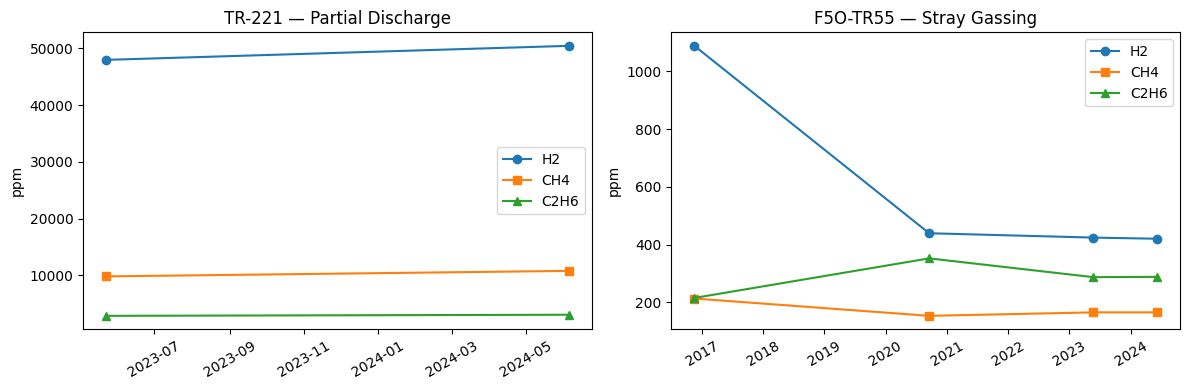

In [6]:
# Visualisasi tren gas kunci untuk 2 kasus demo: TR-221 (Partial Discharge) dan F5O-TR55 (Stray Gassing)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, asset in zip(axes, ["TR-221", "F5O-TR55"]):
    sub = df[df["asset_id"] == asset]
    ax.plot(sub["sample_date"], sub["h2"], marker="o", label="H2")
    ax.plot(sub["sample_date"], sub["ch4"], marker="s", label="CH4")
    ax.plot(sub["sample_date"], sub["c2h6"], marker="^", label="C2H6")
    ax.set_title(f"{asset} — {sub['lab_fault_type'].iloc[-1]}")
    ax.set_ylabel("ppm")
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 4. Composite Risk Score (Isolation Forest)

Pendekatan **cross-sectional**: satu baris = satu (aset, periode sampling). Fitur dari
Trend Engine (Bagian 3), bukan nilai gas mentah. Model belajar pola mayoritas "normal"
dari data ini, lalu memberi `anomaly_score` — makin negatif, makin menyimpang.

Fitur trend saja (delta gas + jumlah parameter memburuk) tidak cukup memisahkan
*level keparahan* (mis. Stray Gassing vs Partial Discharge sama-sama "ada
parameter naik"). Karena itu ditambahkan `rule_fault_severity` — ranking ordinal
dari `rule_fault_type` (hasil rule engine Bagian 2, BUKAN `lab_fault_type`, supaya
model tidak "mengintip" label ground truth). Sempat dicoba one-hot encoding, tapi
itu membuat kategori langka (Thermal Cellulose, Mild Overheating Paper) dianggap
paling anomali cuma karena sedikit sampelnya, bukan karena paling parah — makanya
dipakai ranking ordinal, bukan one-hot.


In [7]:
# Ordinal severity ranking, bukan one-hot -- one-hot bikin kategori langka (Thermal
# Cellulose, Mild Overheating Paper) dianggap anomali cuma karena sedikit sampelnya,
# bukan karena parah. Ranking severity ini konsisten dgn urutan bahaya Duval/IEEE:
# Normal < Stray Gassing/Thermal Fault (Oil) < Thermal Cellulose < Partial Discharge.
FAULT_SEVERITY_RANK = {
    "Normal": 0,
    "Stray Gassing": 1,
    "Thermal Fault (Oil)": 1,
    "Thermal Cellulose": 2,
    "Partial Discharge": 3,
}
df["rule_fault_severity"] = df["rule_fault_type"].map(FAULT_SEVERITY_RANK)

feature_cols = (
    [f"delta_{g}" for g in GAS_COLS]
    + ["rule_status", "n_gas_worsening", "n_parameters_worsening", "rule_fault_severity"]
)
X = df[feature_cols].fillna(0)

model = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
df["anomaly_score"] = model.fit_predict(X)  # -1 = anomali, 1 = normal
df["anomaly_score_raw"] = model.decision_function(X)  # makin negatif makin anomali

ranking = df.sort_values("anomaly_score_raw")[
    ["asset_id", "sample_date", "lab_fault_type", "rule_fault_type", "n_parameters_worsening", "anomaly_score_raw"]
]
print("20 baris paling anomali menurut Composite Risk Score:")
ranking.head(20)

20 baris paling anomali menurut Composite Risk Score:


,asset_id,sample_date,lab_fault_type,rule_fault_type,n_parameters_worsening,anomaly_score_raw
102,TR-44,2023-07-25,Partial Discharge,Partial Discharge,7,-0.332760
87,TR-34,2024-06-06,Partial Discharge,Partial Discharge,7,-0.241592
103,TR-44,2023-11-23,Partial Discharge,Partial Discharge,1,-0.186705
58,TR-221,2024-06-05,Partial Discharge,Partial Discharge,3,-0.168720
160,TR-YDPK,2024-06-06,Partial Discharge,Partial Discharge,4,-0.119198
13,F5O-TR510,2023-05-23,Normal,Normal,4,-0.117360
12,F5O-TR510,2020-09-17,Normal,Normal,0,-0.094645
123,TR-52,2020-09-18,Normal,Partial Discharge,3,-0.091322
24,F5O-TR55,2020-09-17,Normal,Partial Discharge,1,-0.069311
25,F5O-TR55,2023-05-23,Stray Gassing,Partial Discharge,3,-0.064706


In [8]:
# Validasi kualitatif: apakah baris Partial Discharge/Thermal Cellulose (fault aktif nyata)
# memang mendapat skor lebih rendah (lebih anomali) dibanding Normal / Stray Gassing?
summary = df.groupby("lab_fault_type")["anomaly_score_raw"].agg(["mean", "min", "max", "count"])
summary = summary.sort_values("mean")
print("Rata-rata anomaly_score per kategori fault (makin rendah = makin dianggap anomali):")
summary

Rata-rata anomaly_score per kategori fault (makin rendah = makin dianggap anomali):


,mean,min,max,count
lab_fault_type,,,,
Partial Discharge,0.019443,-0.332760,0.148152,16
Stray Gassing,0.031467,-0.064706,0.169435,7
Thermal Cellulose,0.077461,0.013972,0.140950,2
Mild Overheating Paper,0.092238,-0.025546,0.161309,3
Attention,0.127461,0.050115,0.169435,12
Normal,0.143774,-0.117360,0.197012,121


## Ringkasan & Langkah Lanjutan

- **Rule Engine**: `status_match` 80% (129/161 baris) setelah dataset diperluas dari
  21 ke 69 aset (161 sampel) -- rasio ini konsisten dengan versi 21-aset sebelumnya,
  jadi tabel batas IEEE (Tabel 3.2-3.5) di Bagian 2 tampaknya cukup representatif untuk
  kombinasi O2/N2 & usia yang muncul di data ini. Baris yang tidak cocok masih perlu
  ditelusuri satu per satu sebelum tahap produksi.
- **Trend Engine**: kolom `pd_worsening` berasal dari `simulated_pd_data.csv` untuk
  20 aset yang tercakup skrip simulasi -- untuk 49 aset baru hasil transkripsi PDF,
  belum ada data PD (kolom ini NaN/0 untuk mereka). Ini keterbatasan yang jujur, BUKAN
  fabrikasi -- PD tetap simulasi untuk sebagian aset, dan harus diganti pembacaan PD
  riil begitu mapping `asset_id` PD-DGA tersedia di database, sebelum `n_parameters_worsening`
  dipakai untuk klaim apa pun ke Pemeliharaan.
- **Composite Risk Score**: dengan n=161 (naik dari 49) dan `rule_fault_severity` (ranking
  ordinal, bukan one-hot) sebagai fitur, rata-rata `anomaly_score` per `lab_fault_type`
  sekarang berurutan sesuai keparahan: Partial Discharge paling anomali, lalu Stray
  Gassing, Thermal Cellulose, Mild Overheating Paper, Attention, dan Normal paling tidak
  anomali. ini perbaikan nyata dibanding versi 21-aset/one-hot sebelumnya, di mana
  kategori langka (2-3 baris) jadi tampak paling anomali cuma karena jarang, bukan
  karena parah.
- Seluruh 161 baris (69 aset) berasal dari transkripsi manual verbatim 3 laporan lab
  Petrolab (Des 2023, Mar 2024, Jul 2024) -- tidak ada nilai gas yang direkayasa. Beberapa
  kombinasi tanggal-sampel diasumsikan (mis. saat DGA hanya dilakukan pada sebagian dari
  tanggal oil-quality) berdasarkan pencocokan jumlah nilai hasil tes -- disarankan spot-check
  ke PDF asli sebelum dipakai untuk klaim formal di makalah PKM.
